In [32]:
import torch
from torch import nn
from torch.autograd import grad

## setting gpu

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.cuda.init()
print(f"training on device:{device}")

torch.set_float32_matmul_precision('high')

training on device:cuda


In [34]:
class pinn(nn.Module): 
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(3,64),
            nn.Tanh(),

            nn.Linear(64,64),
            nn.Tanh(),

            nn.Linear(64,64),
            nn.Tanh(),

            nn.Linear(64,1)
        )

    def forward(self,t,x,y):
        inputs = torch.cat(
            [t,x,y],
            dim=1
        )

        return self.net(inputs)

In [35]:
def derivative(u, x):
    return grad(
        u,
        x,
        grad_outputs= torch.ones_like(u),
        retain_graph=True,
        create_graph=True
    )[0]

# creating model

In [36]:
model = pinn().to(device)

In [37]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

# pde

### domain points

In [38]:
Nf = 5000
t_f = torch.rand(Nf, 1, device=device, requires_grad=True)
x_f = torch.rand(Nf, 1, device=device, requires_grad=True)
y_f = torch.rand(Nf, 1, device=device, requires_grad=True)

### boundary conditions

In [39]:
Nb = 1000

# bc1: u(t,0,y)
t_b1 = torch.rand(Nb, 1, device=device, requires_grad=True)
x_b1 = torch.zeros(Nb, 1, device=device, requires_grad=True)
y_b1 = torch.rand(Nb, 1, device=device, requires_grad=True)

# bc2: u(t,1,y)
t_b2 = torch.rand(Nb, 1, device=device, requires_grad=True)
x_b2 = torch.ones(Nb, 1, device=device, requires_grad=True)
y_b2 = torch.rand(Nb, 1, device=device, requires_grad=True)

# bc3: u(t,x,0)
t_b3 = torch.rand(Nb, 1, device=device, requires_grad=True)
x_b3 = torch.rand(Nb, 1, device=device, requires_grad=True)
y_b3 = torch.zeros(Nb, 1, device=device, requires_grad=True)

# bc3: u(t,x,1)
t_b4 = torch.rand(Nb, 1, device=device, requires_grad=True)
x_b4 = torch.rand(Nb, 1, device=device, requires_grad=True)
y_b4 = torch.ones(Nb, 1, device=device, requires_grad=True)

# target
u_b_true = torch.ones(Nb, 1, device=device)

### inital condition

In [40]:
Ni = 2000
t_i = torch.zeros(Ni, 1, device=device, requires_grad=True)
x_i = torch.rand(Ni, 1, device=device, requires_grad=True)
y_i = torch.rand(Ni, 1, device=device, requires_grad=True)

# Create a Gaussian Hot Spot in the dead center (x=0.5, y=0.5)
# Using torch.exp to calculate the bell curve
u_i_true = torch.exp(-((x_i - 0.5)**2 + (y_i - 0.5)**2) / 0.05).detach()

# training

In [41]:
a = 0.1
epochs = 8000

for epoch in range(epochs):
    optimizer.zero_grad()

    #pde
    u_f = model(t_f, x_f, y_f)
    u_t = derivative(u_f, t_f)
    
    u_x = derivative(u_f, x_f)
    u_xx = derivative(u_x, x_f)
    
    u_y = derivative(u_f, y_f)
    u_yy = derivative(u_y, y_f)

    loss_pde = torch.mean((u_t - a * (u_xx + u_yy))**2)

    u_b1_pred = model(t_b1, x_b1, y_b1)
    u_b2_pred = model(t_b2, x_b2, y_b2)
    u_b3_pred = model(t_b3, x_b3, y_b3)
    u_b4_pred = model(t_b4, x_b4, y_b4)

    # ==========================
    # 2. Calculate the Gradients (Derivatives)
    # ==========================
    # Left and Right walls block horizontal flow (X-axis)
    u_x_b1 = derivative(u_b1_pred, x_b1) 
    u_x_b2 = derivative(u_b2_pred, x_b2)
    
    # Top and Bottom walls block vertical flow (Y-axis)
    u_y_b3 = derivative(u_b3_pred, y_b3)
    u_y_b4 = derivative(u_b4_pred, y_b4)

    # ==========================
    # 3. Calculate Neumann Loss
    # ==========================
    # Force all these derivatives to be exactly 0 (perfect insulation)
    loss_bc = (
        torch.mean((u_x_b1 - 0)**2) + 
        torch.mean((u_x_b2 - 0)**2) + 
        torch.mean((u_y_b3 - 0)**2) + 
        torch.mean((u_y_b4 - 0)**2)
    )

    u_i_pred = model(t_i, x_i, y_i)
    loss_ic = torch.mean((u_i_pred - u_i_true)**2)

    loss = loss_pde + loss_bc + loss_ic

    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print(f"e={epoch} loss={loss} lpde={loss_pde} lbc={loss_bc} lic={loss_ic}")


e=0 loss=0.07091308385133743 lpde=7.694355008425191e-05 lbc=0.014306520111858845 lic=0.05652961879968643
e=1000 loss=0.021394390612840652 lpde=0.0033110342919826508 lbc=0.0009184168302454054 lic=0.017164940014481544
e=2000 loss=0.007198040373623371 lpde=0.0015921677695587277 lbc=0.00059740204596892 lic=0.005008470267057419
e=3000 loss=0.002564280526712537 lpde=0.0009372186614200473 lbc=0.0003386679454706609 lic=0.0012883939780294895
e=4000 loss=0.0015478463610634208 lpde=0.0006206618854776025 lbc=0.00016690432676114142 lic=0.0007602801779285073
e=5000 loss=0.0011075843358412385 lpde=0.0004980290541425347 lbc=0.00014248929801397026 lic=0.00046706595458090305
e=6000 loss=0.0013170719612389803 lpde=0.0007996778003871441 lbc=0.00021576487051788718 lic=0.00030162930488586426
e=7000 loss=0.0005155570106580853 lpde=0.00028837533318437636 lbc=7.687171455472708e-05 lic=0.0001503099629189819


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import plotly.graph_objects as go
from IPython.display import HTML

In [43]:
# 1. Create the shared 100x100 spatial grid once
x_val = torch.linspace(0, 1, 100)
y_val = torch.linspace(0, 1, 100)

# Create the 2D meshgrid
X, Y = torch.meshgrid(x_val, y_val, indexing='ij')

# Flatten it and send it to the GPU for the neural network
x_flat = X.reshape(-1, 1).to(device)
y_flat = Y.reshape(-1, 1).to(device)

t_val = 1
t_flat = torch.full_like(x_flat, t_val).to(device)

model.eval()
with torch.no_grad():
    u_pred = model(t_flat, x_flat, y_flat)

U_pred = u_pred.reshape(100, 100).cpu().numpy()

print("Shared grid generated successfully!")

Shared grid generated successfully!


NameError: name 'U' is not defined

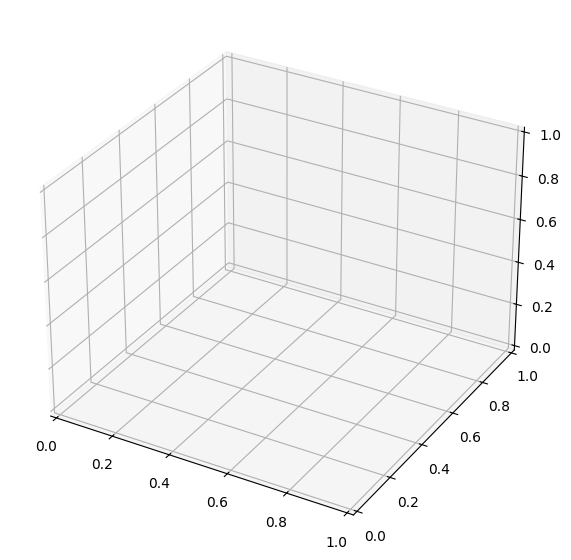

In [44]:
fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X.cpu().numpy(),
    Y.cpu().numpy(),
    U,
    cmap='jet',
    linewidth=0,
    antialiased=True
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u(x,y,t)')

ax.set_title(f'2D Heat Equation Solution at t={t_val}')

fig.colorbar(surf, shrink=0.7)

plt.show()

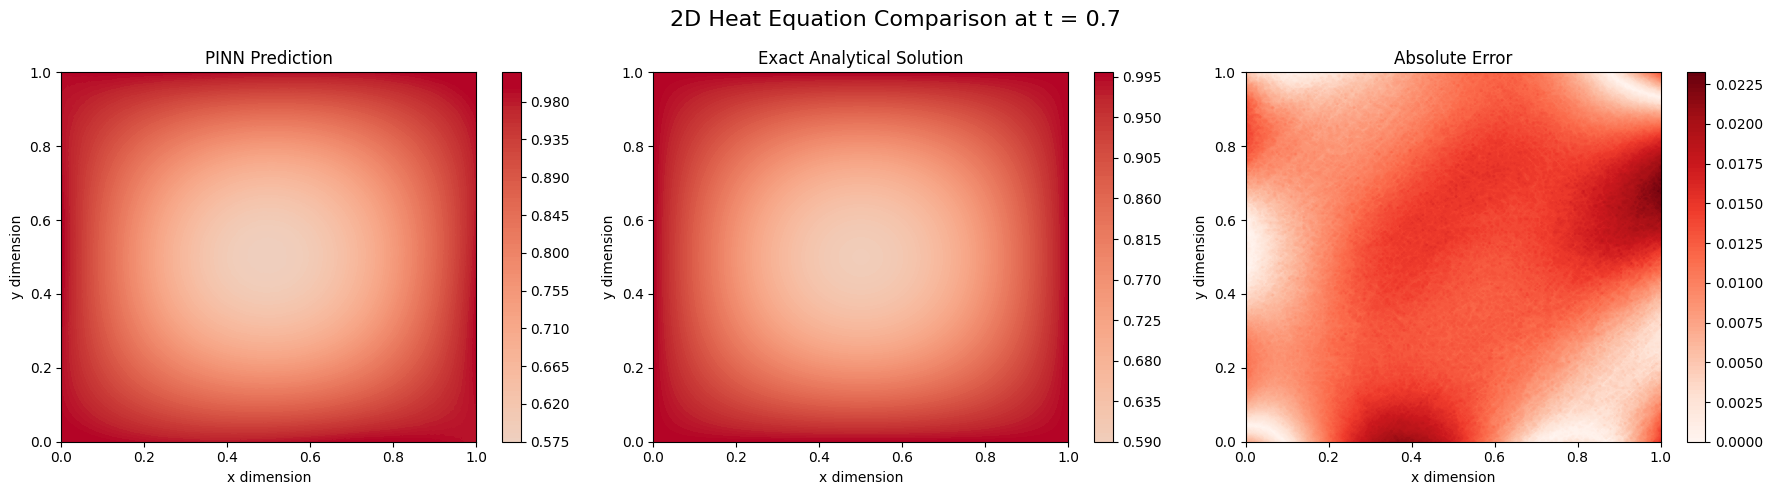

<Figure size 640x480 with 0 Axes>

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PARAMETERS
# =========================
resolution = 200
t_val = 0.7
a = 0.1  # Thermal diffusivity

# =========================
# CREATE GRID
# =========================
x = torch.linspace(0, 1, resolution)
y = torch.linspace(0, 1, resolution)

X, Y = torch.meshgrid(x, y, indexing='ij')

x_flat = X.reshape(-1, 1).to(device)
y_flat = Y.reshape(-1, 1).to(device)

t_flat = torch.full_like(x_flat, t_val).to(device)

# =========================
# PINN PREDICTION
# =========================
model.eval()

with torch.no_grad():
    u_pred = model(t_flat, x_flat, y_flat)

U_pred = u_pred.reshape(resolution, resolution).cpu().numpy()

# =========================
# EXACT SOLUTION (Fourier Series)
# =========================
X_np = X.numpy()
Y_np = Y.numpy()

# We sum the first 25 odd harmonics of the Fourier series
v = np.zeros_like(X_np)
terms = 25 
for n in range(1, terms * 2, 2):  # Odd terms: 1, 3, 5...
    for m in range(1, terms * 2, 2):
        coeff = 16.0 / (n * m * np.pi**2)
        spatial = np.sin(n * np.pi * X_np) * np.sin(m * np.pi * Y_np)
        temporal = np.exp(-(n**2 + m**2) * np.pi**2 * a * t_val)
        v += coeff * spatial * temporal

# The exact temperature is 1 (boundary heat) minus the cooling effect
U_exact = 1.0 - v

# =========================
# ABSOLUTE ERROR
# =========================
error = np.abs(U_exact - U_pred)

# =========================
# PLOT
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plots = [
    (U_pred, "PINN Prediction"),
    (U_exact, "Exact Analytical Solution"),
    (error, "Absolute Error")
]

for i, (ax, (data, title)) in enumerate(zip(axes, plots)):
    
    if i < 2:
        # For the temperatures, lock the scale from 0 to 1 with cool/warm colors
        contour = ax.contourf(
            X_np, Y_np, data, 
            levels=100, cmap='coolwarm', vmin=0, vmax=1
        )
    else:
        # For the error, use a red scale that auto-adjusts to the maximum error
        contour = ax.contourf(
            X_np, Y_np, data, 
            levels=100, cmap='Reds'
        )

    ax.set_title(title)
    ax.set_xlabel('x dimension')
    ax.set_ylabel('y dimension')

    fig.colorbar(contour, ax=ax)

plt.suptitle(f'2D Heat Equation Comparison at t = {t_val}', fontsize=16)
plt.tight_layout()
plt.show()
plt.savefig("comparison at t=3.png")

In [ ]:
# Render Interactive Graph using Plotly's version of Viridis
fig = go.Figure(data=[go.Surface(
    z=U_pred, 
    x=x_val.numpy(), 
    y=y_val.numpy(), 
    colorscale='jet' 
)])

fig.update_layout(
    title=f'2D Heat Equation at t = {t_val}',
    autosize=False,
    width=800, 
    height=600,
    scene=dict(
        xaxis_title='X (Space)', 
        yaxis_title='Y (Space)', 
        zaxis_title='Temperature (u)'
    )
)
fig.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# =========================
# PARAMETERS
# =========================
resolution = 100  # 100 is best for rendering animations quickly
total_frames = 40 # The number of steps between t=0 and t=1

# =========================
# CREATE SHARED GRID
# =========================
x = torch.linspace(0, 1, resolution)
y = torch.linspace(0, 1, resolution)
X, Y = torch.meshgrid(x, y, indexing='ij')

x_flat = X.reshape(-1, 1).to(device)
y_flat = Y.reshape(-1, 1).to(device)

# =========================
# SET UP THE FIGURE
# =========================
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# =========================
# ANIMATION LOOP FUNCTION
# =========================
def update_3d_frame(frame):
    ax.clear()
    
    # Map the current frame to a time value between 0.0 and 1.0
    t_val = frame / (total_frames - 1)
    t_flat = torch.full_like(x_flat, t_val).to(device)
    
    # PINN Prediction
    model.eval()
    with torch.no_grad():
        u_pred = model(t_flat, x_flat, y_flat)
        
    U = u_pred.reshape(resolution, resolution).cpu().numpy()
    
    # Plot the smooth surface (linewidth=0, antialiased=False)
    surf = ax.plot_surface(
        X.numpy(), Y.numpy(), U, 
        cmap='coolwarm', 
        rstride=1, cstride=1, linewidth=0, antialiased=False,
        vmin=0, vmax=1 # Lock the color scale
    )
    
    # CRITICAL: Lock the Z-axis so the camera stays completely still
    ax.set_zlim(0, 1) 
    
    ax.set_xlabel('X dimension')
    ax.set_ylabel('Y dimension')
    ax.set_zlabel('Temperature (u)')
    ax.set_title(f'Smooth 3D Heat Diffusion: t = {t_val:.2f}')
    
    return surf,

# =========================
# RENDER VIDEO
# =========================
# blit=False is required for 3D animations in Matplotlib
ani = animation.FuncAnimation(fig, update_3d_frame, frames=total_frames, blit=False)


# 1. Save the animation as a GIF!
# fps (frames per second) controls the speed. 
# 10 fps for 40 frames = a 4-second GIF.
ani.save('2D_heat_equation.gif', writer='pillow', fps=10)
print("GIF successfully saved to your folder!")

# 2. Close the static figure
plt.close() 

HTML(ani.to_jshtml())

GIF successfully saved to your folder!
